# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 

# 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [1]:
import sys
dataset = 'Fe-Mo'  #'Cr-Co-W'
atoms = dataset.split('-')
from Tools.DatasetTools.EVCurvesTools import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
import pickle
import os

In [2]:
from scipy.optimize import curve_fit

In [3]:
from ase.eos import EquationOfState, birchmurnaghan

In [4]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [5]:
def get_key_for_curves(EVC: pd.core.series.Series, key='str') -> pd.core.series.Series:
    r2 = {}
    for index, data in EVC.items():
        r2[index]={}
        for params, curve in data.items():
            r2[index].update({params: curve[key]})
    return pd.Series(r2)
    

In [6]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

<AxesSubplot:ylabel='Frequency'>

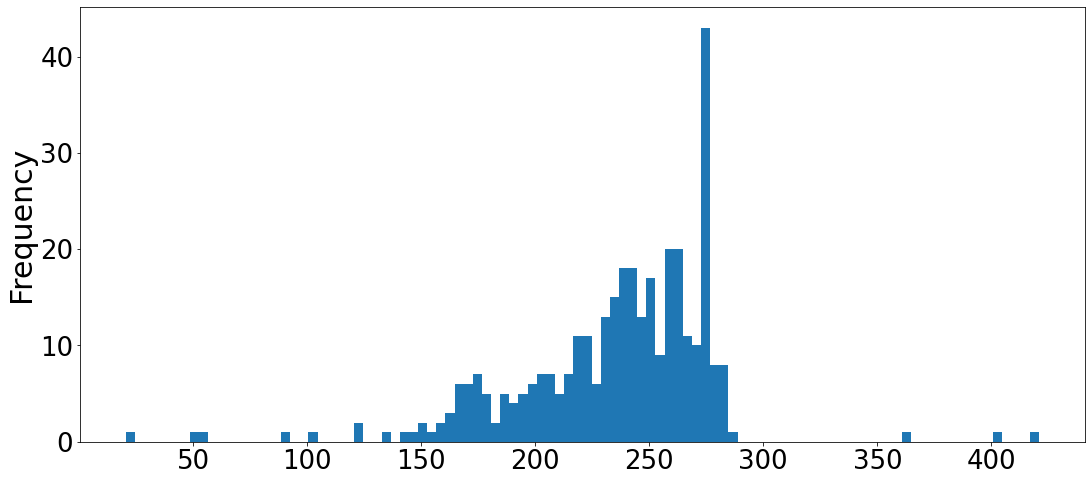

In [7]:
PBS.query('B0>0').B0.plot.hist(bins=100)

In [8]:
# PBS[PBS.index.str.contains('R')]

## Investigate ev-curves

In [9]:
fittedcurvesloc = os.path.join(dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(dataset,'evcurves.json' )
goodnessloc = os.path.join(dataset, 'goodness.json')
force = True

In [10]:
Mo_R = 'Mo_sv53.R.NM'

In [11]:
Fe_R = 'Fe_pv53.R.NM'

In [12]:
if not os.path.exists(fittedcurvesloc) or force:
    if not os.path.exists(evcurvesloc) or force:
        print('redoing')

        EV = Evcurves(Indexes = PBS.index, atoms=dataset.split(), dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = PBS['deltak'], encuts = PBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = get_goodness(EVcurves)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            if index in R2.keys():
                if key in R2[index].keys():
                    data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    print('B')
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = get_key_for_curves(EVcurves, 'r2')
    Goodness = get_key_for_curves(EVcurves, 'IsGood')
    Fits = get_key_for_curves(EVcurves, 'fit')

redoing


  0%|          | 0/351 [00:00<?, ?it/s]

  0%|          | 0/351 [00:00<?, ?it/s]

In [13]:
EVcurves[EVcurves.index.str.contains('R')]

Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv53.R.NM                       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv53.R-Mo.FM                    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv53.R.NM                       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv50Mo_sv3.R-BBAAAAAAAAA.NM     {'xc=PBE-PAW.E=450.dk=0.020': 

In [14]:
EVcurves_df = pd.DataFrame.from_dict(EVcurves.to_dict(), orient='index')

In [15]:
R2_df = pd.DataFrame.from_dict(R2.to_dict(), orient='index')

In [16]:
Fits_df = pd.DataFrame.from_dict(Fits.to_dict(), orient='index')

In [17]:
Better_evcurves = {}

In [18]:
for index, evcurves in EVcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

In [19]:
Better_evcurves_df = pd.DataFrame.from_dict(Better_evcurves, orient='index')

In [20]:
ev_fit_results_df = pd.DataFrame.from_dict(Better_evcurves_df.ev_fit_results.to_dict(), orient='index')

In [21]:
ev_fit_results_df

,E_murn,V_murn,B_murn,Bdev_murn
Fe_pv8Mo_sv22.sigma-BBABB.FM,-10.004507,14.954763,224.285410,7.275164
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-10.006896,14.130625,237.907324,4.207050
Fe_pv4Mo_sv20.C36-ABBBB.FM,-10.007837,16.270923,204.470374,4.245173
Fe_pv3Mo_sv10.mu-ABBBA.FM,-10.008565,15.378254,402.123952,-106.774345
Fe_pv5Mo_sv24.chi-AABB.FM,-10.015010,15.751001,216.183583,3.467979
...,...,...,...,...
Fe_pv4Mo_sv2.C15-A2B.FM,-9.135294,12.307425,177.924519,-2.724562
Fe_pv2Mo_sv4.C15-AB2.FM,-9.455649,15.885323,175.903078,3.940169
Fe_pv8Mo_sv16.C36-BAABB.NM,-9.611603,14.705902,232.342308,4.170758
Fe_pv4Mo_sv9.mu-BBBAA.FM,-9.612627,15.244665,207.420038,4.000323


In [22]:
fit_results = Better_evcurves_df.fit.map( lambda f : {name: val for name, val in zip(['E_murn', 'B_murn', 'Bdev_murn', 'V_murn'], f)})

In [23]:
fit_results_df = pd.DataFrame.from_dict(fit_results.to_dict(), orient='index')

In [24]:
fit_results_df

,E_murn,B_murn,Bdev_murn,V_murn
Fe_pv8Mo_sv22.sigma-BBABB.FM,-10.004508,224.504766,7.261221,14.954790
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-10.006897,237.945535,4.214880,14.130620
Fe_pv4Mo_sv20.C36-ABBBB.FM,-10.007837,204.312645,4.333180,16.270956
Fe_pv3Mo_sv10.mu-ABBBA.FM,-10.008460,310.905451,-36.764476,15.362713
Fe_pv5Mo_sv24.chi-AABB.FM,-10.015010,216.131543,3.519924,15.750987
...,...,...,...,...
Fe_pv4Mo_sv2.C15-A2B.FM,-9.135293,177.930697,-2.191295,12.307032
Fe_pv2Mo_sv4.C15-AB2.FM,-9.455656,175.245844,4.106883,15.886094
Fe_pv8Mo_sv16.C36-BAABB.NM,-9.611603,232.376504,4.183038,14.705893
Fe_pv4Mo_sv9.mu-BBBAA.FM,-9.612627,207.354253,4.060334,15.244654


In [25]:
negative_B0_index = fit_results_df.query('B_murn < 0').index

In [26]:
negative_B0_index

Index(['Fe_pv13Mo_sv16.chi-ABAB.FM', 'Fe_pv10Mo_sv14.C36-ABBBA.FM'], dtype='object')

# Test On Mo R

In [27]:
Better_evcurves_df.loc[Mo_R].IsGood

True

In [28]:
indexofgoodsamples = Better_evcurves_df.query('IsGood == True').index

In [29]:
GoodBS = PBS.loc[indexofgoodsamples]
BadBS = PBS.loc[Better_evcurves_df.index.difference(indexofgoodsamples)]

In [30]:
GoodBS = GoodBS[~GoodBS.index.str.contains('sigma-BABBB.FM|sigma-AABBB.FM|mu-BBBBA.FM')]

In [31]:
BadBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv1.bcc.FM,bulk bcc.FM,11.352006 A,-8.254018,170.727430 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.016,0,1,...,Fe_pv,,1,0,1,1.000000,0.000000,0.000825,0.000825,0.000825
Fe_pv10Mo_sv14.C36-ABBAB.FM,bulk C36-ABBAB.FM,14.791477 A,-9.413408,194.257707 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,14,24,0.416667,0.583333,0.403571,0.403571,0.403571
Fe_pv10Mo_sv14.C36-ABBBA.FM,bulk C36-ABBBA.FM,13.975813 A,-9.446499,-157.020416 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,14,24,0.416667,0.583333,0.370480,0.370480,0.370480
Fe_pv10Mo_sv14.C36-BABAB.FM,bulk C36-BABAB.FM,14.595271 A,-9.414958,420.901429 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,14,24,0.416667,0.583333,0.402021,0.402021,0.402021
Fe_pv10Mo_sv14.C36-BABBA.FM,bulk C36-BABBA.FM,14.599262 A,-9.464137,249.350538 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,14,24,0.416667,0.583333,0.352842,0.352842,0.352842
Fe_pv11Mo_sv2.mu-AAABA.FM,bulk mu-AAABA.FM,8.318826 A,-8.453835,-271.520165 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,11,2,13,0.846154,0.153846,0.213000,0.213000,0.213000
Fe_pv11Mo_sv2.mu-AABAA.FM,bulk mu-AABAA.FM,12.022507 A,-8.459843,-6867.530562 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,11,2,13,0.846154,0.153846,0.206992,0.206992,0.206992
Fe_pv12Mo_sv12.C36-AAABB.FM,bulk C36-AAABB.FM,14.631811 A,-9.098397,173.539303 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,12,12,24,0.500000,0.500000,0.495420,0.495420,0.495420
Fe_pv12Mo_sv17.chi-BBAB.FM,bulk chi-BBAB.FM,14.233801 A,-9.552726,203.021600 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,12,17,29,0.413793,0.586207,0.271949,0.271949,0.271949
Fe_pv13Mo_sv16.chi-ABAB.FM,bulk chi-ABAB.FM,14.058613 A,-9.439938,-320.617353 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,13,16,29,0.448276,0.551724,0.292394,0.292394,0.292394


## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [32]:
GoodBS = GoodBS.loc[~GoodBS.index.str.contains(r'\..*[UD]+$') ]

## Obtain some info from indexes

In [33]:
Features = Featurizer(GoodBS)

In [34]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.214165,0.214165,0.214165
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,20,30,0.333333,0.666667,0.033246,0.033246,0.033246
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,4,20,24,0.166667,0.833333,0.478629,0.478629,0.478629
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,5,24,29,0.172414,0.827586,0.456066,0.456066,0.456066
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,15,38,53,0.283019,0.716981,0.153952,0.133922,0.111544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv16Mo_sv8.C36-ABBAA.NM,bulk C36-ABBAA,12.475250 A,-8.914609,257.520617 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.018,0,2,...,Fe_pv,Mo_sv,16,8,24,0.666667,0.333333,0.232895,0.185712,0.132999
Fe_pv4Mo_sv2.C15-A2B.FM,bulk C15-A2B.FM,12.307425 A,-9.135294,177.924519 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.018,0,2,...,Fe_pv,Mo_sv,4,2,6,0.666667,0.333333,0.012198,0.012198,0.012198
Fe_pv8Mo_sv16.C36-BAABB.NM,bulk C36-BAABB,14.705902 A,-9.611603,232.342308 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.018,0,2,...,Fe_pv,Mo_sv,8,16,24,0.333333,0.666667,0.428562,0.404971,0.378614
Fe_pv4Mo_sv9.mu-BBBAA.FM,bulk mu-BBBAA.FM,15.244665 A,-9.612627,207.420038 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.018,0,2,...,Fe_pv,Mo_sv,4,9,13,0.307692,0.692308,0.496180,0.496180,0.496180


In [35]:
GoodBS.shape

(279, 22)

## translate structures to their bases

# TODo this sould be in tools, as a phase cleaner

In [36]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    GoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=GoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [37]:
Target_Class

Fe_pv8Mo_sv22.sigma-BBABB.FM       sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM      sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM           C36
Fe_pv5Mo_sv24.chi-AABB.FM            chi
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM        R
                                   ...  
Fe_pv16Mo_sv8.C36-ABBAA.NM           C36
Fe_pv4Mo_sv2.C15-A2B.FM              C15
Fe_pv8Mo_sv16.C36-BAABB.NM           C36
Fe_pv4Mo_sv9.mu-BBBAA.FM              mu
Fe_pv14Mo_sv16.sigma-AABBA.FM      sigma
Length: 279, dtype: object

In [38]:
dataset

'Fe-Mo'

In [39]:
DescriptorsLoc = os.path.join(dataset,'Descriptors')
if not os.path.exists(DescriptorsLoc):
    os.makedirs(DescriptorsLoc)

In [40]:
Target_Class.to_pickle(os.path.join(DescriptorsLoc, 'ClassLabels.pkl'))

In [41]:
GoodBS['Phase'] = Target_Class

In [42]:
GoodBS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000
mean,-9.329292,1.845878,233.833932,13.503262,13.333333,10.215054,23.548387,0.504959,0.495041,0.251255,0.228968,0.204067
std,0.749058,0.361714,37.292275,1.832762,11.246102,9.598242,13.998085,0.292276,0.292276,0.163215,0.163491,0.167763
min,-10.932826,1.000000,-2.685409,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,-0.015696,-0.042837,-0.085493
25%,-9.922030,2.000000,217.366676,12.242977,5.000000,2.500000,13.000000,0.266667,0.265409,0.124226,0.099778,0.071628
50%,-9.319754,2.000000,241.156159,13.300993,10.000000,8.000000,24.000000,0.500000,0.500000,0.227057,0.190274,0.168422
75%,-8.786448,2.000000,260.523677,14.840264,18.000000,16.000000,30.000000,0.734591,0.733333,0.360616,0.336242,0.308816
max,-7.780040,2.000000,287.396036,16.550514,56.000000,52.000000,56.000000,1.000000,1.000000,0.720407,0.720388,0.720388


# some E-V curves, good and bad

## sample bad

In [43]:
sample_bad_index = BadBS.sample(n=5).index#.append(pd.Index(['Mo_sv53.R.NM'])).unique()

In [44]:
sample_bad = EVcurves[sample_bad_index] #[BadBS.index].dropna().sample(n=min(5, BadBS.shape[0]))

In [45]:
plt.rc('font', size=22)
plt.rc('figure', figsize=(12,8))

In [46]:
sample_bad_r2 = R2[sample_bad.index]

In [47]:
sample_bad_fit = Fits[sample_bad.index]

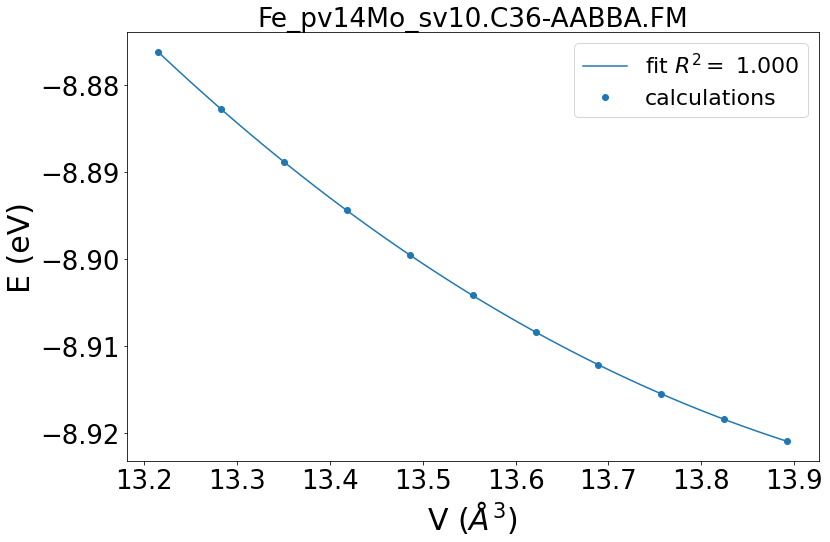

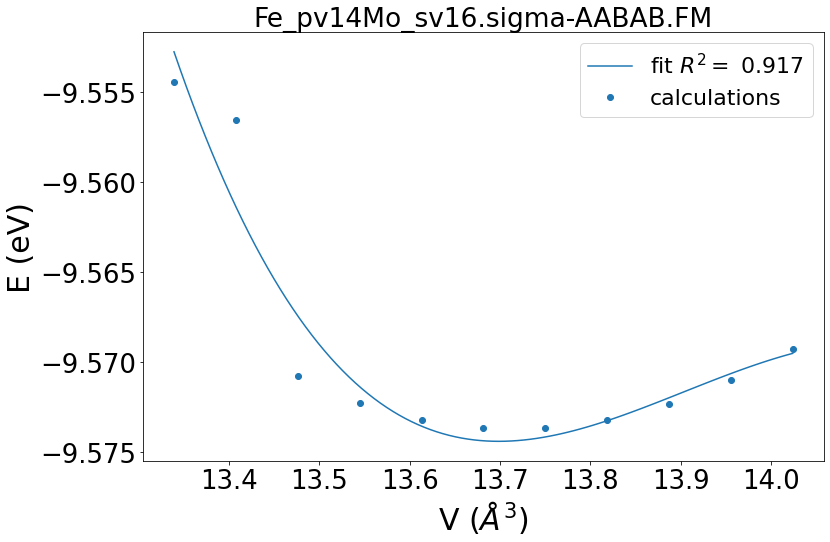

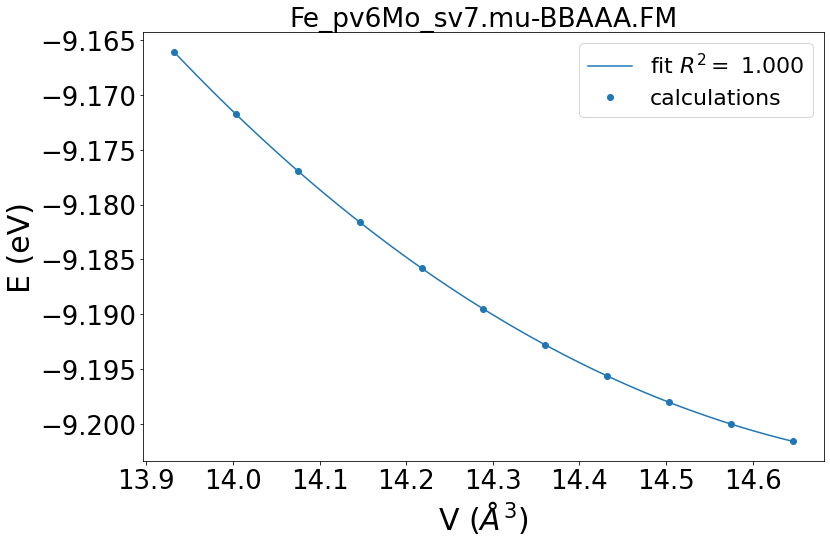

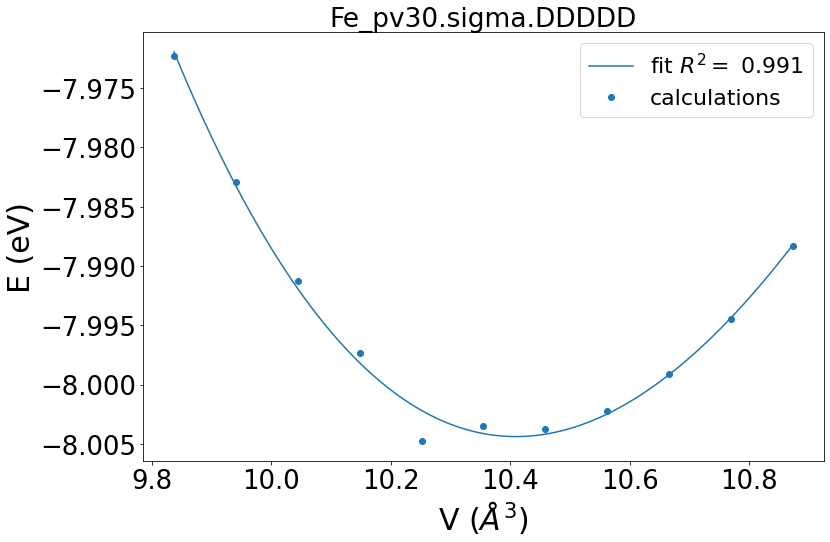

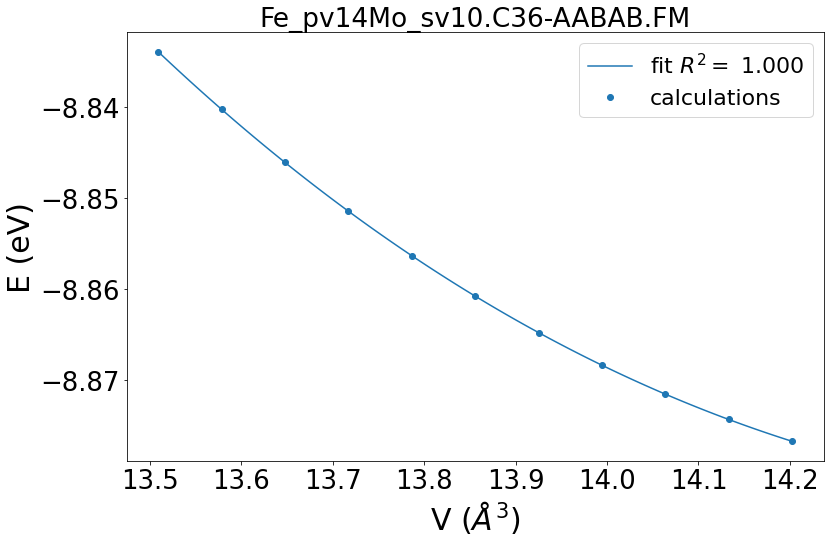

In [48]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)

# casos interesantes 

In [49]:
interesting_cases = ['Fe_pv28Mo_sv1.chi-BAAA.FM', 'Fe_pv11Mo_sv2.mu-AAABA.FM', 'Fe_pv1.fcc.FM', 'Fe_pv1.fcc.FM']

In [50]:
Better_evcurves_df.IsGood[interesting_cases]

Fe_pv28Mo_sv1.chi-BAAA.FM    False
Fe_pv11Mo_sv2.mu-AAABA.FM    False
Fe_pv1.fcc.FM                 True
Fe_pv1.fcc.FM                 True
Name: IsGood, dtype: bool

In [51]:
Fits.loc[interesting_cases][0]

{'xc=PBE-PAW.E=450.dk=0.020': array([-8.23994851e+00,  7.97575010e-01,  5.13504221e+03,  1.15394111e+01])}

In [52]:
Better_evcurves_df.ev_fit_results[interesting_cases][0]

{'E_murn': -8.240007,
 'V_murn': 11.555812,
 'B_murn': 20.484025,
 'Bdev_murn': 59.173261}

([<Figure size 864x576 with 1 Axes>,
  <Figure size 864x576 with 1 Axes>,
  <Figure size 864x576 with 1 Axes>,
  <Figure size 864x576 with 1 Axes>],
 [<AxesSubplot:title={'center':'Fe_pv28Mo_sv1.chi-BAAA.FM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>,
  <AxesSubplot:title={'center':'Fe_pv11Mo_sv2.mu-AAABA.FM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>,
  <AxesSubplot:title={'center':'Fe_pv1.fcc.FM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>,
  <AxesSubplot:title={'center':'Fe_pv1.fcc.FM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>])

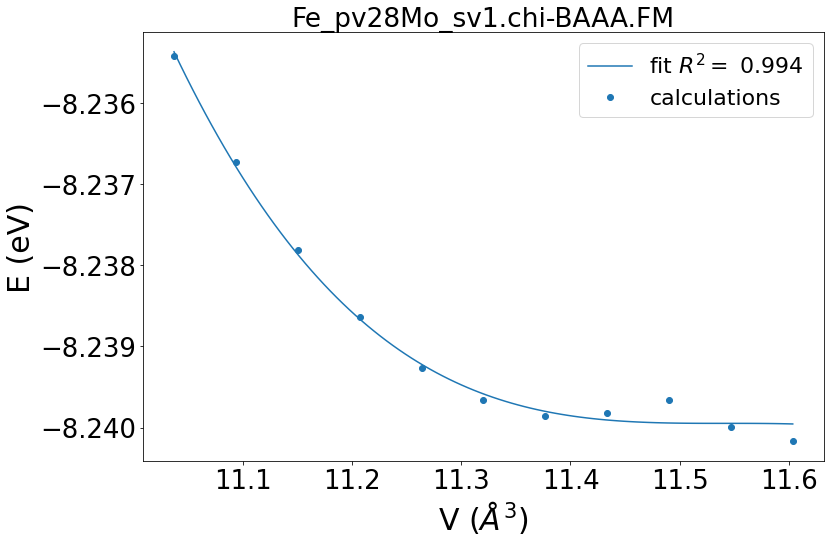

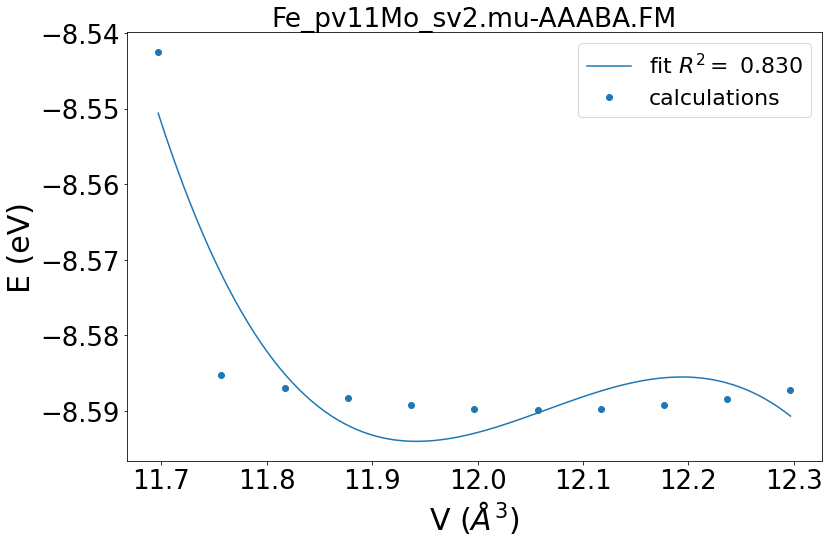

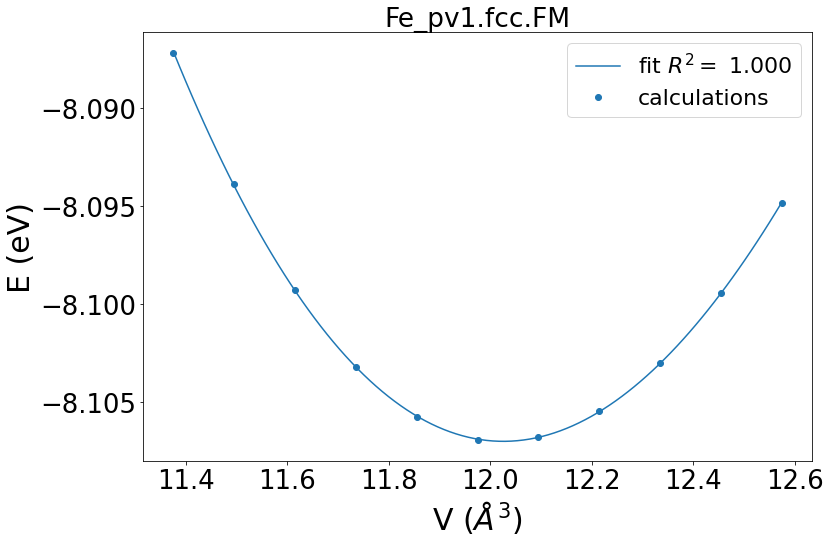

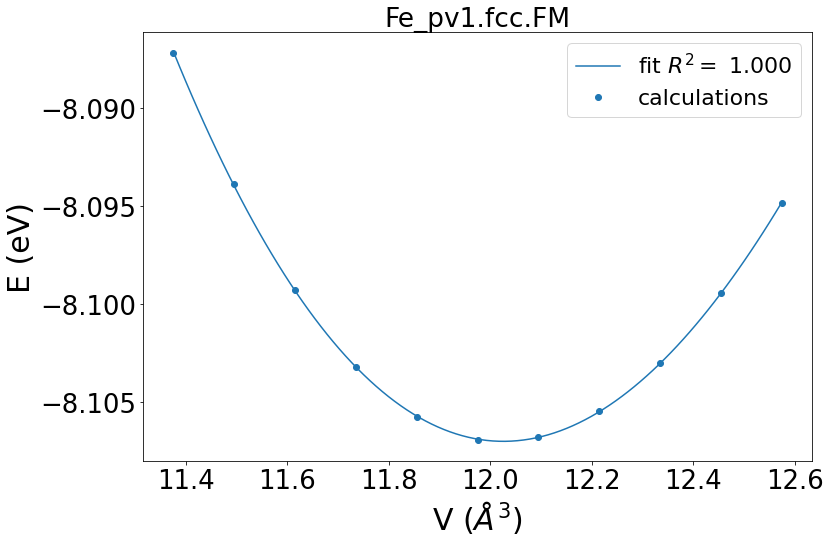

In [53]:


plot_curves(EVcurves[interesting_cases], Fits[interesting_cases], R2[interesting_cases])

## R2=0

In particular I would like to solve this fittings,

In [54]:
zero_r2_index = Better_evcurves_df[Better_evcurves_df.r2 == 0].index

In [55]:
Better_evcurves_df.ev_fit_results[zero_r2_index]

Series([], Name: ev_fit_results, dtype: object)

In [56]:
sample_zero_r2 = EVcurves[zero_r2_index]

In [57]:
plot_curves(EVcurves[zero_r2_index], Fits[zero_r2_index], R2[zero_r2_index])

([], [])


# Sample good

In [58]:
GoodBS.shape

(279, 23)

In [59]:
sample_good = EVcurves[GoodBS.index].dropna().sample(n=5)

In [60]:
sample_good

Fe_pv3Mo_sv10.mu-ABBAB.FM       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv1Mo_sv3.L12-AB3.NM         {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv8Mo_sv22.sigma-BBABB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv8Mo_sv16.C36-BAABB.NM      {'xc=PBE-PAW.E=450.dk=0.018': {'evcurve': {'V'...
Fe_pv10Mo_sv3.mu-BAAAB.FM       {'xc=PBE-PAW.E=450.dk=0.019': {'evcurve': {'V'...
dtype: object

In [61]:
Goodness[sample_good.index]

Fe_pv3Mo_sv10.mu-ABBAB.FM       {'xc=PBE-PAW.E=450.dk=0.020': True}
Fe_pv1Mo_sv3.L12-AB3.NM         {'xc=PBE-PAW.E=450.dk=0.020': True}
Fe_pv8Mo_sv22.sigma-BBABB.NM    {'xc=PBE-PAW.E=450.dk=0.020': True}
Fe_pv8Mo_sv16.C36-BAABB.NM      {'xc=PBE-PAW.E=450.dk=0.018': True}
Fe_pv10Mo_sv3.mu-BAAAB.FM       {'xc=PBE-PAW.E=450.dk=0.019': True}
dtype: object

In [62]:
sample_good_r2 = R2[sample_good.index]

In [63]:
sample_good_fit = Fits[sample_good.index]

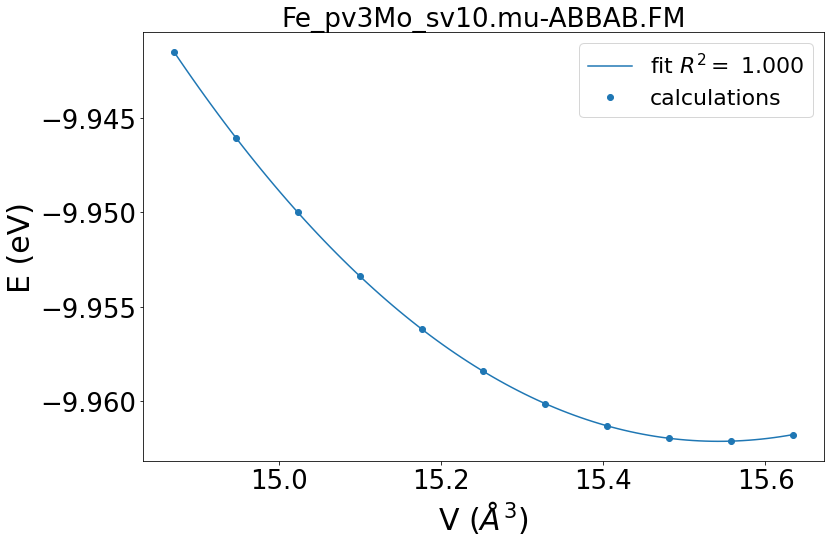

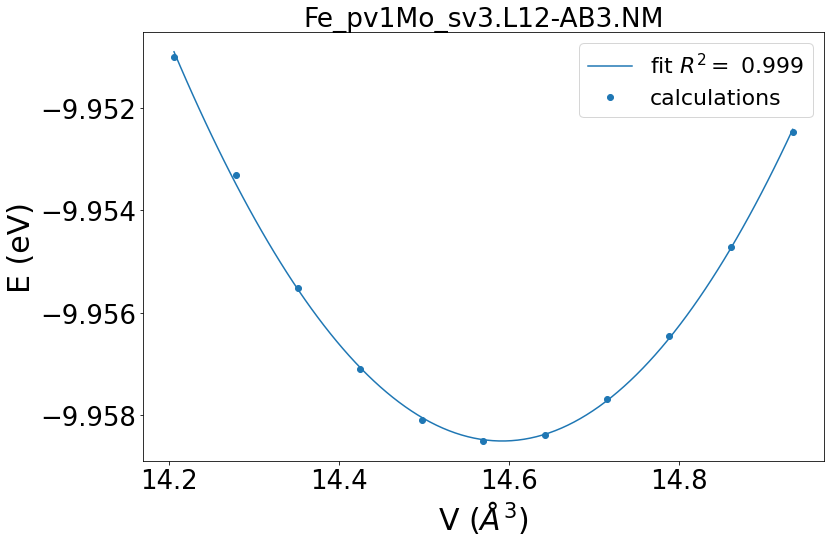

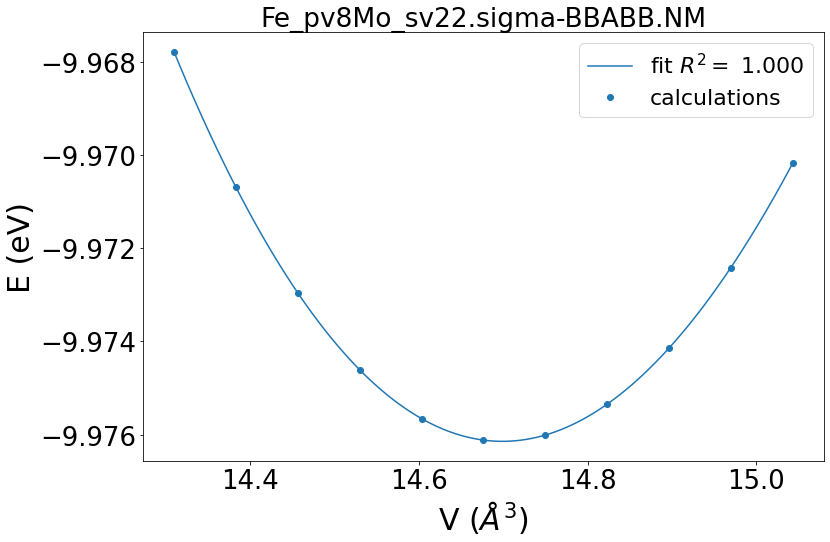

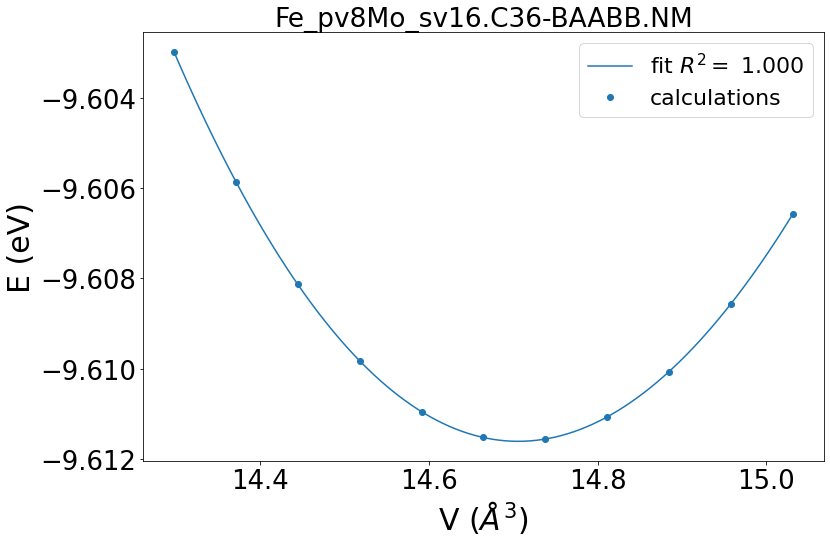

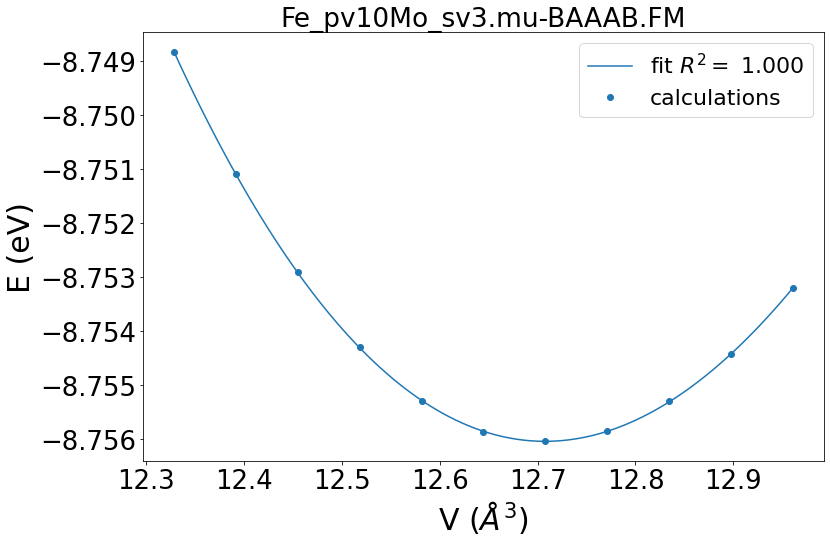

In [64]:
figurecollection, axcollection  = plot_curves(sample_good, sample_good_fit, sample_good_r2)

still high and low B0s

<AxesSubplot:>

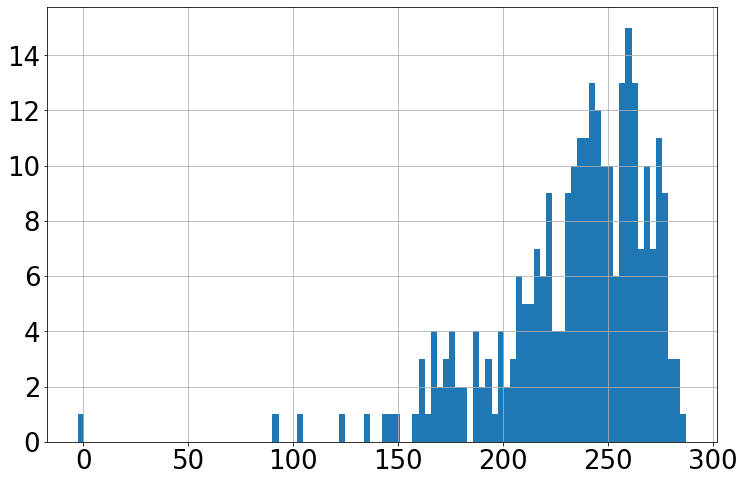

In [65]:
GoodBS.B0.hist(bins=100)

In [66]:
GoodBS.query('nelem == 1').B0.idxmin()

'Fe_pv1.fcc.FM'

In [67]:
GoodBS.query('nelem == 1').B0.idxmax()

'Fe_pv2.hcp.NM'

In [68]:
sample_max_B0 = GoodBS.query('nelem == 1').B0.idxmax()

In [69]:
sample_min_B0 = GoodBS.query('nelem == 1').B0.idxmin()

In [70]:
sample_min_B0

'Fe_pv1.fcc.FM'

In [71]:
GoodBS.B0[sample_min_B0]

-2.685409

In [72]:
theminbo = EVcurves_df.loc[sample_min_B0].dropna()

In [73]:
theminbo[0]

{'evcurve': {'V': array([12.57375, 12.454  , 12.33425, 12.2145 , 12.09475, 11.975  ,
         11.85525, 11.7355 , 11.61575, 11.496  , 11.37625]),
  'E': array([-8.0948565 , -8.09943775, -8.1029985 , -8.105469  , -8.10679775,
         -8.10694   , -8.1057545 , -8.1032315 , -8.09928975, -8.09387675,
         -8.08718175])},
 'ev_fit_results': {'E_murn': -7.912043,
  'V_murn': 0.0,
  'B_murn': -2.685409,
  'Bdev_murn': 1.076746},
 'r2': 0.9999429546582033,
 'fit': array([ -8.10700408, 167.19141302,   3.47075467,  12.02593387]),
 'IsGood': True,
 'calc_param': 'xc=PBE-PAW.E=480.dk=0.020'}

In [74]:
sample_max_B0

'Fe_pv2.hcp.NM'

In [75]:
GoodBS.B0[sample_max_B0]

287.396036

In [76]:
selection = ((GoodBS.B0>=GoodBS.B0[sample_min_B0]) & (GoodBS.B0<=GoodBS.B0[sample_max_B0]))

In [77]:
selection.sum()

279

In [78]:
selection_stricter = ((GoodBS.B0>1.1*GoodBS.B0[sample_min_B0]) & (GoodBS.B0<0.90*GoodBS.B0[sample_max_B0]) &
                     (list(R2[sample_max_B0].values())[0] > 0.998))

In [79]:
selection_stricter

Fe_pv8Mo_sv22.sigma-BBABB.FM       True
Fe_pv10Mo_sv20.sigma-ABBAB.FM      True
Fe_pv4Mo_sv20.C36-ABBBB.FM         True
Fe_pv5Mo_sv24.chi-AABB.FM          True
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    True
                                   ... 
Fe_pv16Mo_sv8.C36-ABBAA.NM         True
Fe_pv4Mo_sv2.C15-A2B.FM            True
Fe_pv8Mo_sv16.C36-BAABB.NM         True
Fe_pv4Mo_sv9.mu-BBBAA.FM           True
Fe_pv14Mo_sv16.sigma-AABBA.FM      True
Name: B0, Length: 279, dtype: bool

In [80]:
samples_wrong_b0 = GoodBS[~selection].index

In [81]:
len(samples_wrong_b0)

0

<AxesSubplot:ylabel='Frequency'>

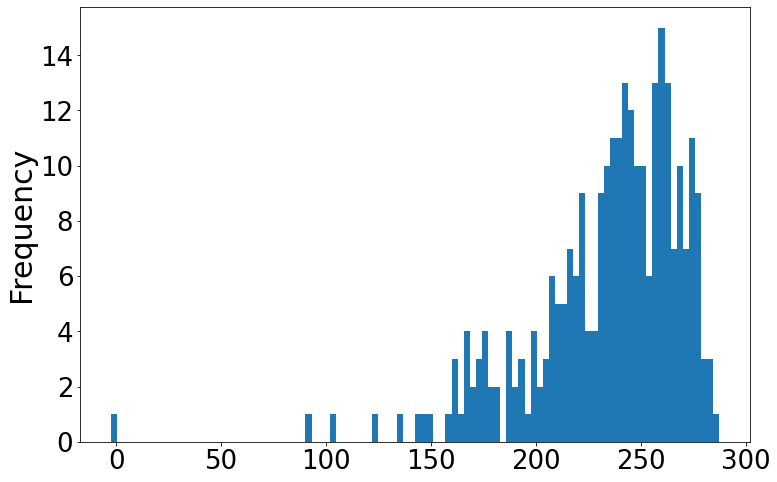

In [82]:
GoodBS.B0.plot.hist(bins=100)

In [83]:
samples_wrong_b0

Index([], dtype='object')

In [84]:
curve_wrong_b0 = EVcurves[samples_wrong_b0]

In [85]:
r2_wrong_b0 = R2[samples_wrong_b0]

In [86]:
fits_wrong_b0 = Fits[samples_wrong_b0]

In [87]:
curve_wrong_b0

Series([], dtype: object)

In [88]:
figurecollection, axcollection  = plot_curves(curve_wrong_b0, fits_wrong_b0, r2_wrong_b0)
for ax, index  in zip(axcollection, samples_wrong_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

In [89]:
GoodBS.drop(index=samples_wrong_b0, inplace=True)

In [90]:
samples_low_b0 = GoodBS.query('B0 < 150').index

In [91]:
curve_low_b0 = EVcurves[samples_low_b0]

In [92]:
r2_low_b0 = R2[samples_low_b0]

In [93]:
fits_low_b0 = Fits[samples_low_b0]

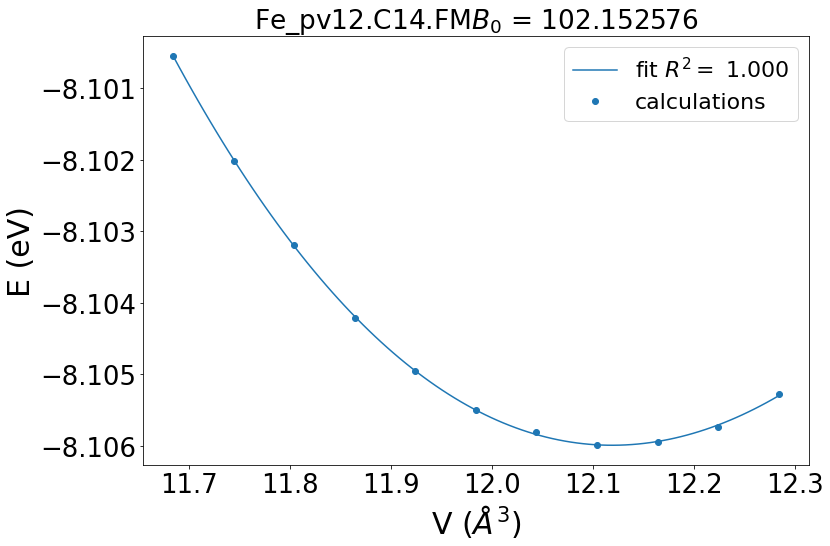

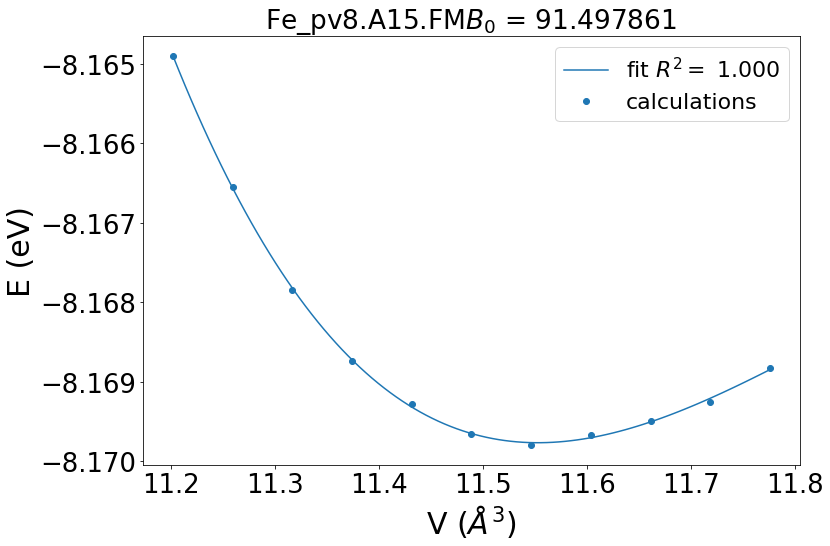

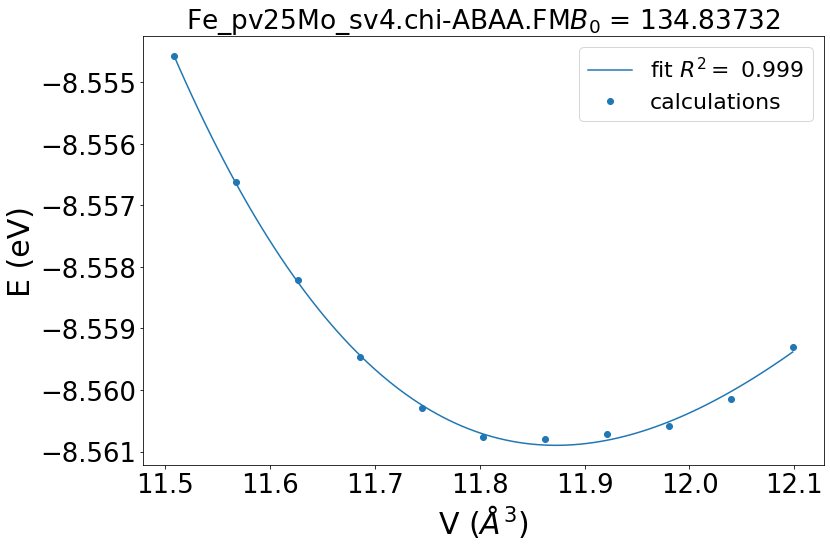

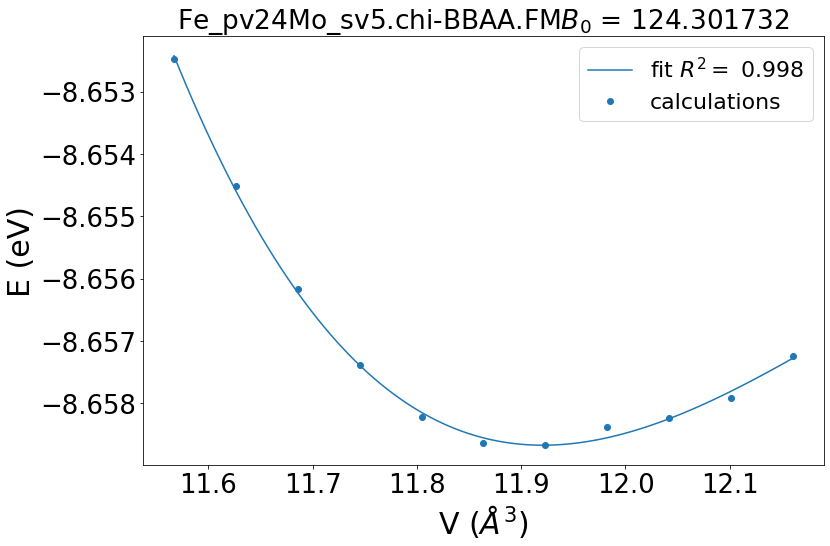

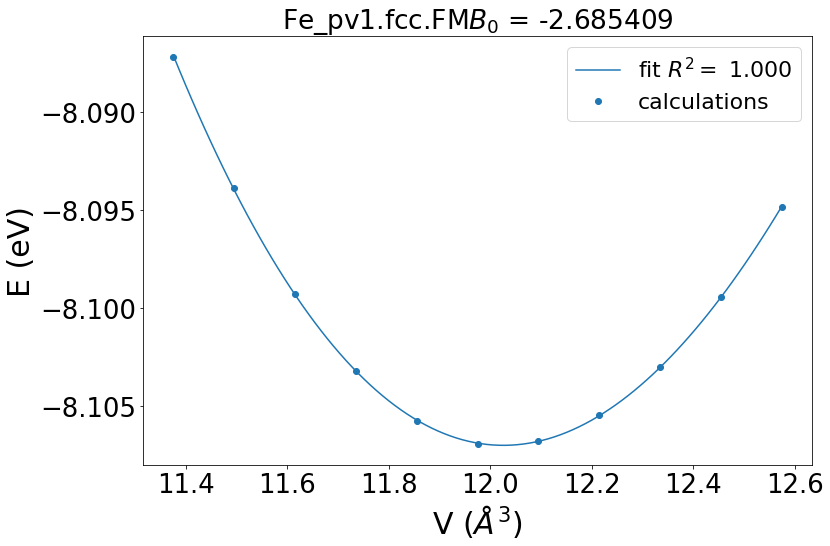

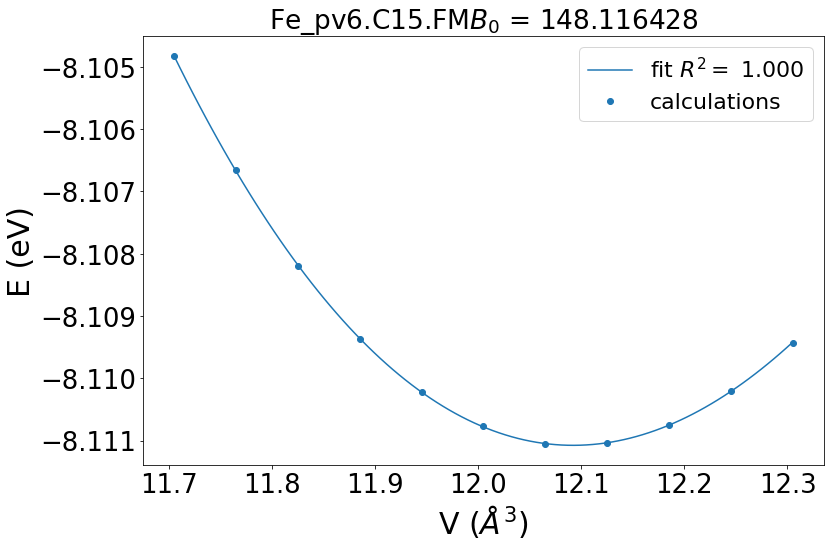

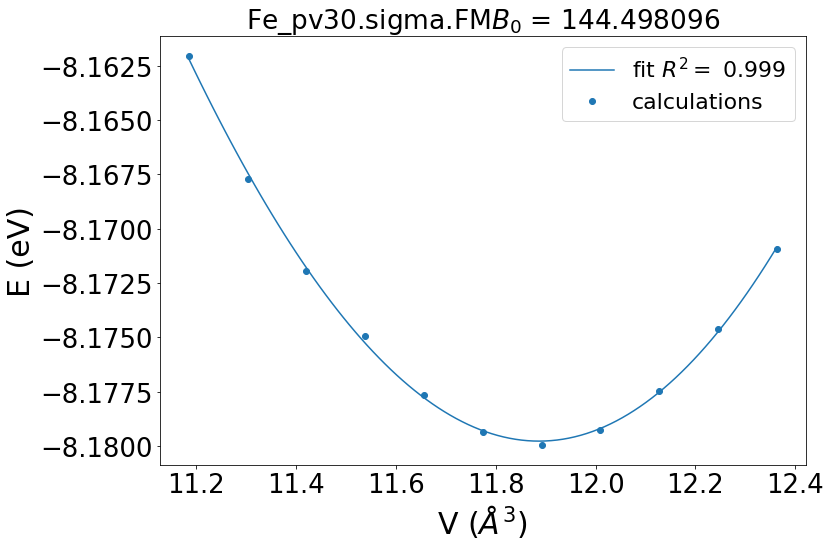

In [94]:
figurecollection, axcollection  = plot_curves(curve_low_b0, fits_low_b0, r2_low_b0)
for ax, index  in zip(axcollection, samples_low_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

# Differences between fits and available data

In [95]:
diff_fit_to_dataset = PBS.E0 - fit_results_df.E_murn

In [96]:
large_diffs = (diff_fit_to_dataset / PBS.E0).abs()>0.001

In [97]:
pd.concat ( [PBS[large_diffs].E0, fit_results_df.E_murn[large_diffs]], axis=  1 )

,E0,E_murn
Mo_sv2.hcp.FM,-10.496688,-9.298978
Mo_sv2.hcp.NM,-10.497856,-9.298898
Mo_sv12.C14.NM,-10.553573,-10.208050
Mo_sv24.C36.NM,-10.564355,-8.672993
Mo_sv13.mu.FM,-10.623993,-10.117556
Mo_sv13.mu.NM,-10.623993,-9.447215
Mo_sv53.R.NM,-10.625314,-9.573485
Mo_sv29.chi.NM,-10.664757,-9.292416
Mo_sv30.sigma.FM,-10.766680,-9.582373
Mo_sv30.sigma.NM,-10.766693,-8.711015


In [98]:
pd.concat ( [PBS.V0, PBS.E0, fit_results_df.E_murn], axis=  1 )[large_diffs & Better_evcurves_df.IsGood].shape

(12, 3)

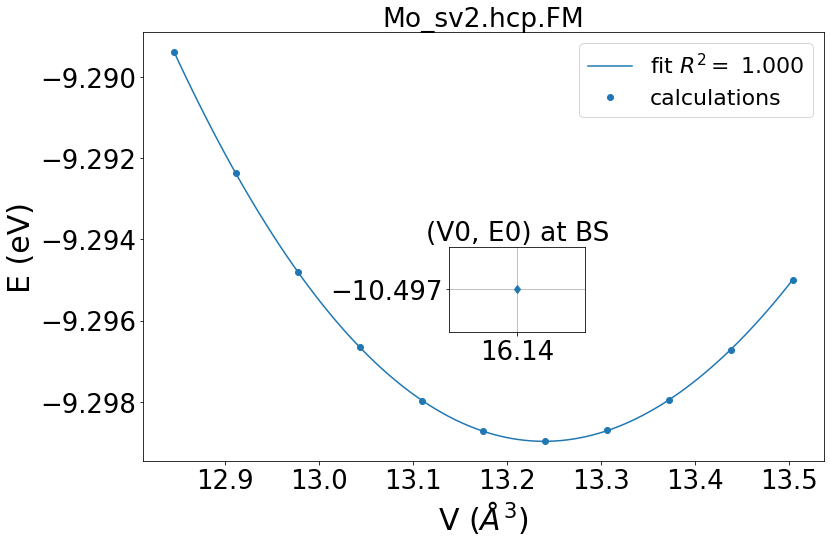

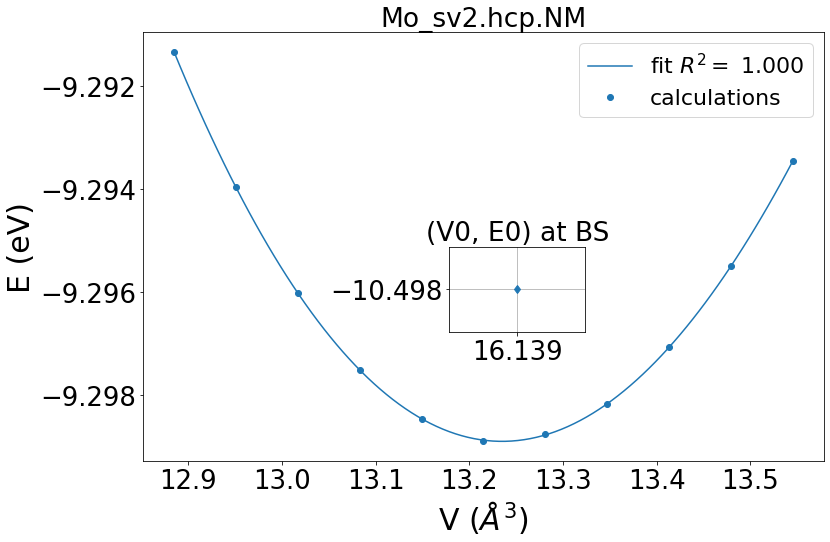

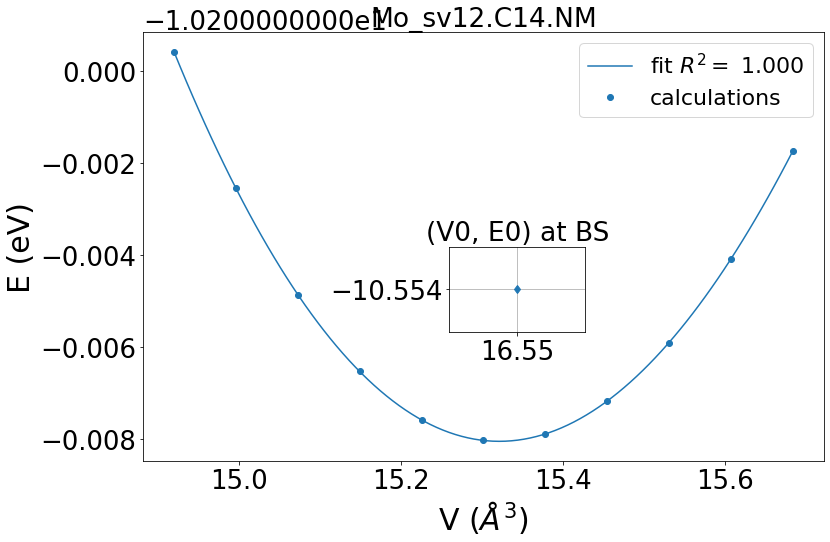

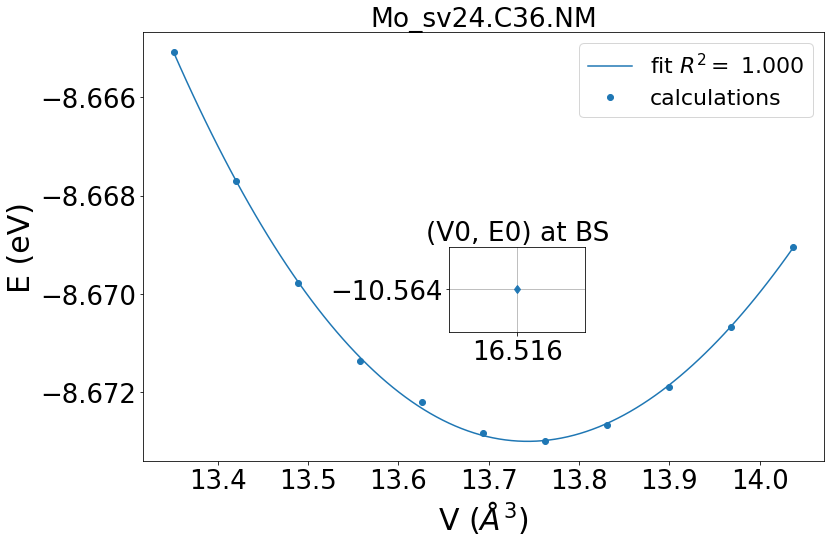

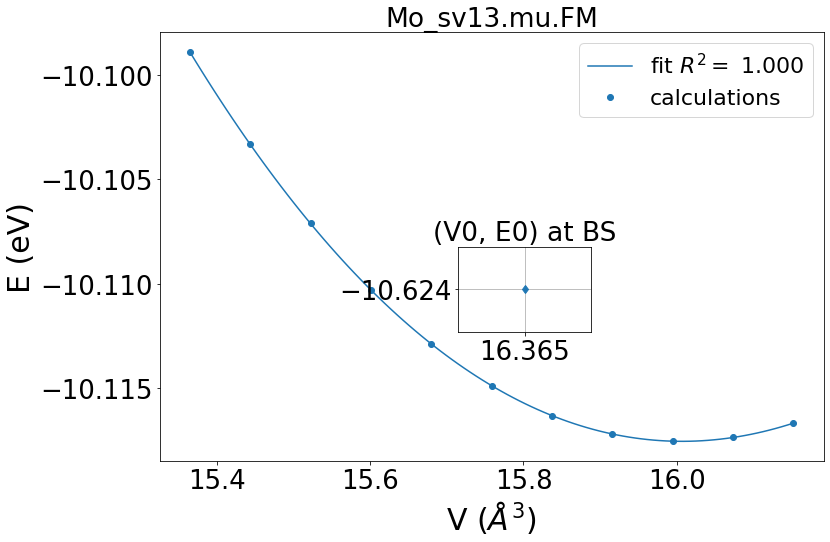

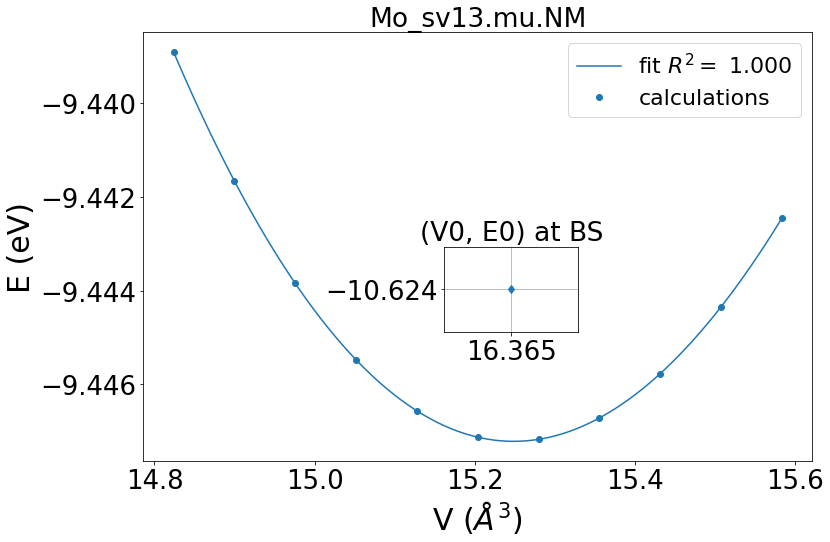

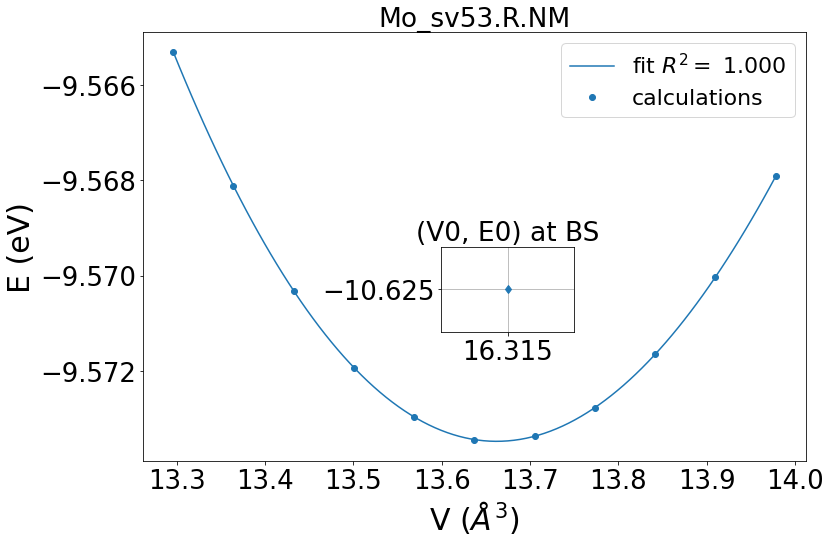

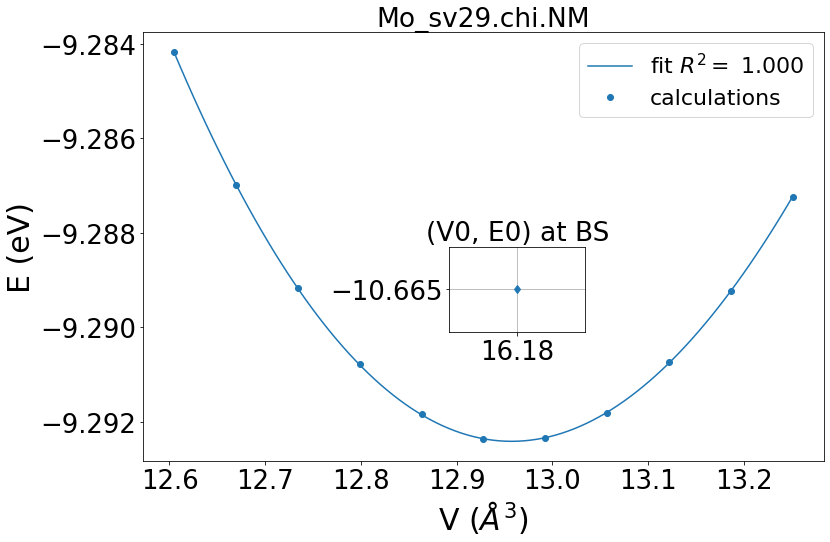

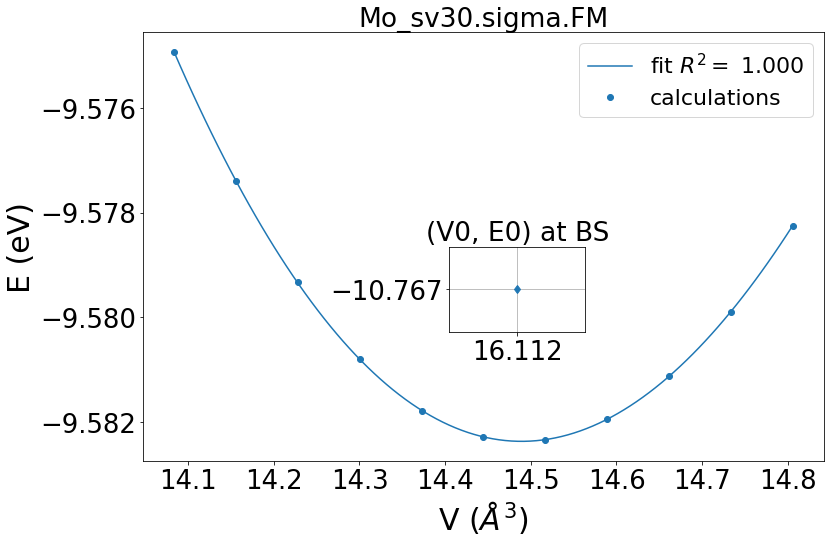

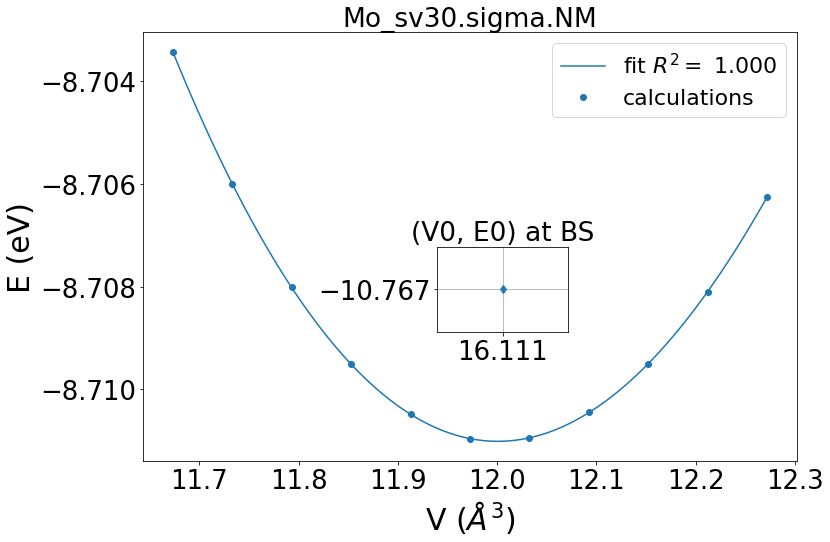

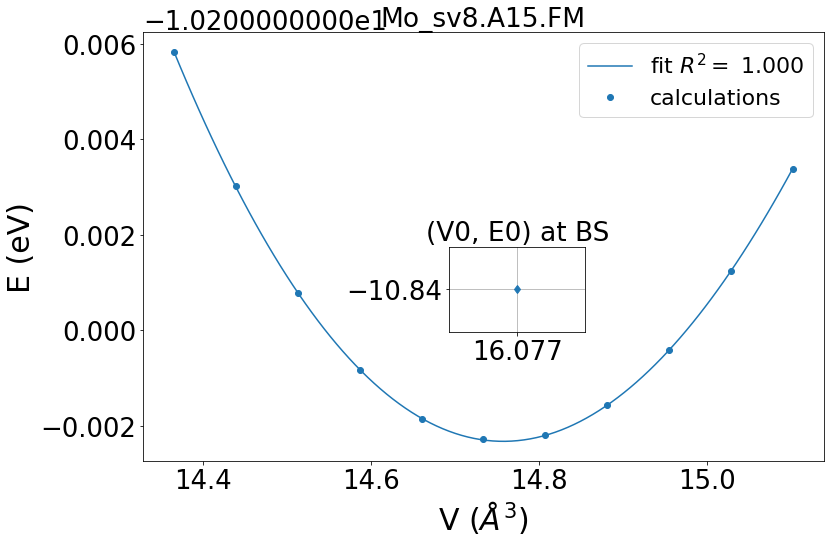

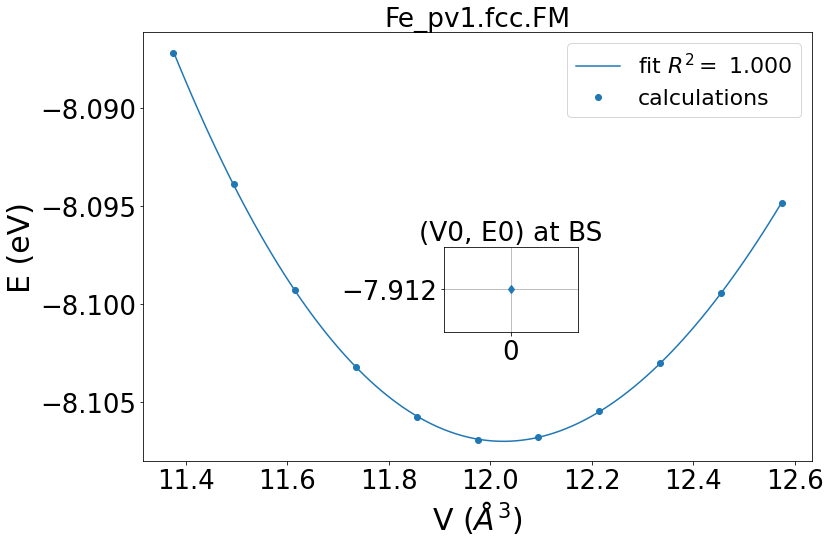

In [99]:
figs, axs = plot_curves(EVcurves[large_diffs & Better_evcurves_df.IsGood], Fits[large_diffs & Better_evcurves_df.IsGood], R2[large_diffs & Better_evcurves_df.IsGood])
for fig, ax  in zip(figs, axs):
    index = ax.title.get_text()
    V0, E0 = PBS[['V0','E0']].loc[index].values
    axins = ax.inset_axes([0.45, 0.3, 0.2, 0.2])
    axins.plot([V0], [E0], 'd')
    axins.set_title('(V0, E0) at BS')
    axins.set_xticks([V0])
    axins.set_yticks([E0])
    axins.grid(visible=True)
    


# Save for later use 

In [100]:
curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
GoodBS.to_pickle(curatedbs)

<AxesSubplot:>

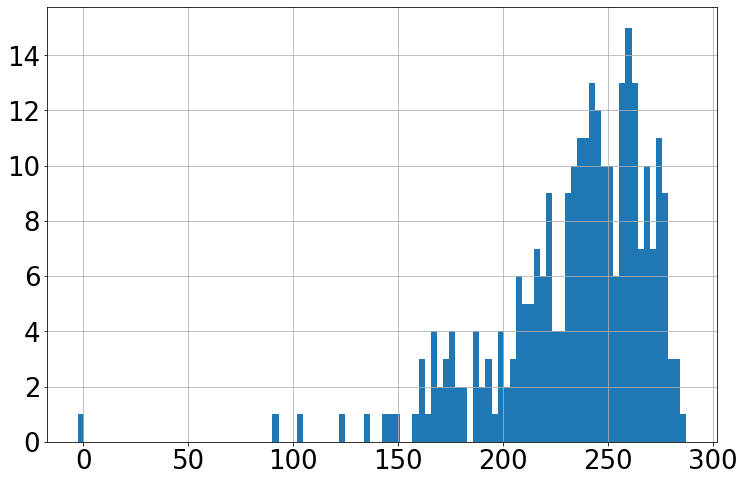

In [101]:
GoodBS.B0.hist(bins=100)

In [102]:
PBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.214165,0.214165,0.214165
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,10,20,30,0.333333,0.666667,0.033246,0.033246,0.033246
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,4,20,24,0.166667,0.833333,0.478629,0.478629,0.478629
Fe_pv3Mo_sv10.mu-ABBBA.FM,bulk mu-ABBBA.FM,15.378254 A,-10.008565,402.123952 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,3,10,13,0.230769,0.769231,0.306238,0.306238,0.306238
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,5,24,29,0.172414,0.827586,0.456066,0.456066,0.456066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,3,10,13,0.230769,0.769231,0.341566,0.325233,0.306987
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.242554,0.223681,0.202596
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,1,3,4,0.250000,0.750000,0.276893,0.276893,0.276893
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333,0.227592,0.227592,0.227592
